# Progreso del modelo de CO$_2$ y preparación del estimador

**Material de presentación — resultados consolidados, no recalibración**

Este notebook organiza resultados ya existentes de tres trabajos de calibración, del análisis histórico Hampel–Butterworth y del estudio temperatura–CO$_2$. No ejecuta optimizaciones ni altera parámetros científicos. Su objetivo es separar con claridad:

1. lo que el modelo ya explica;
2. lo que el preprocesamiento cambia en la medición;
3. lo que todavía debe validarse antes de incorporar CO$_2$ a un estimador de estados.


## 1. Fuentes y alcance

In [1]:
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
while ROOT.name != "pyomo-doe" and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if ROOT.name != "pyomo-doe":
    raise RuntimeError("Ejecute este notebook desde el repositorio pyomo-doe o un descendiente")

FM = ROOT / "fermentation_model"
LAB_RESULTS = FM / "laboratory_2026" / "results"
PILOT25_RESULTS = FM / "pilot_2025" / "results" / "co2_solubility_integrated_doe"
PILOT26_RESULTS = FM / "pilot_2026" / "results" / "co2_solubility_cross_lot_validation_2026"
LAB_CAL_RESULTS = LAB_RESULTS / "co2_matrix_cross_validation_2026"
FILTER_RESULTS = LAB_RESULTS / "co2_filter_delay_analysis"
RAW_ROOT = FM / "data" / "Laboratorio 2026" / "raw_data"
PRESENTATION_FIGURES = LAB_RESULTS / "presentation_figures"
PRESENTATION_FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 115,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

reused = {
    "piloto 2025 · comparación de formulaciones": PILOT25_RESULTS / "plots" / "co2_benchmark" / "co2_benchmark_25170.png",
    "laboratorio 2026 · holdout entre matrices": LAB_CAL_RESULTS / "figures" / "heldout_cross_matrix_validation.png",
    "piloto 2026 · holdout entre lotes": PILOT26_RESULTS / "figures" / "heldout_cross_lot_validation.png",
    "retardo por experimento": FILTER_RESULTS / "figures" / "delay_comparison_by_experiment.png",
    "acoplamiento térmico LAB005 F2 PT2": FILTER_RESULTS / "figures" / "thermal_coupling_lab005_F2_pt2.png",
}
missing = [str(path) for path in reused.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Faltan artefactos requeridos:\n" + "\n".join(missing))

print("Repositorio:", ROOT)
print("Artefactos reutilizados:", len(reused))
print("Directorio de figuras nuevas:", PRESENTATION_FIGURES)

Repositorio: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe
Artefactos reutilizados: 5
Directorio de figuras nuevas: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe\fermentation_model\laboratory_2026\results\presentation_figures


## 2. Del modelo biológico a la señal de CO$_2$

La variable que verá el estimador no es la producción biológica instantánea: entre los estados y el sensor existe una capa de acumulación/disolución y liberación. La temperatura (T(t)) y los controles conocidos (u(t)) entran como señales exógenas; **(T) no es un estado**.


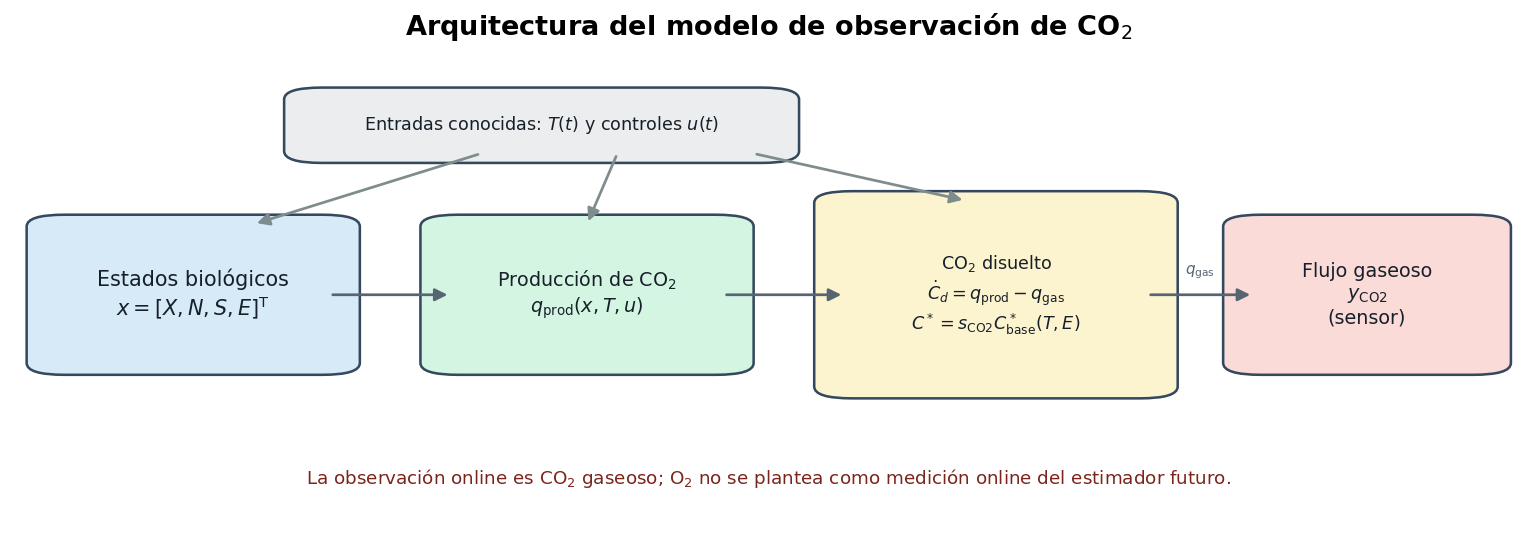

Guardada: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe\fermentation_model\laboratory_2026\results\presentation_figures\co2_model_architecture.png


In [2]:
def add_box(ax, xy, width, height, text, facecolor, edgecolor="#34495e", fontsize=11):
    patch = FancyBboxPatch(
        xy, width, height, boxstyle="round,pad=0.02,rounding_size=0.025",
        linewidth=1.6, facecolor=facecolor, edgecolor=edgecolor
    )
    ax.add_patch(patch)
    ax.text(xy[0] + width / 2, xy[1] + height / 2, text,
            ha="center", va="center", fontsize=fontsize, color="#17202a")
    return patch


def add_arrow(ax, start, end, color="#566573", text=None, text_offset=(0, 0.03)):
    arrow = FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=16,
                            linewidth=1.7, color=color)
    ax.add_patch(arrow)
    if text:
        ax.text((start[0] + end[0]) / 2 + text_offset[0],
                (start[1] + end[1]) / 2 + text_offset[1], text,
                ha="center", va="bottom", fontsize=9.5, color=color)


fig, ax = plt.subplots(figsize=(13.5, 4.8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

add_box(ax, (0.03, 0.34), 0.18, 0.30,
        r"Estados biológicos" + "\n" + r"$x=[X,N,S,E]^\mathsf{T}$",
        "#d6eaf8", fontsize=13)
add_box(ax, (0.29, 0.34), 0.18, 0.30,
        r"Producción de CO$_2$" + "\n" + r"$q_{\rm prod}(x,T,u)$",
        "#d5f5e3", fontsize=12)
add_box(ax, (0.55, 0.29), 0.20, 0.40,
        r"CO$_2$ disuelto" + "\n" + r"$\dot C_d=q_{\rm prod}-q_{\rm gas}$" + "\n" +
        r"$C^*=s_{\rm CO2}C^*_{\rm base}(T,E)$",
        "#fcf3cf", fontsize=11)
add_box(ax, (0.82, 0.34), 0.15, 0.30,
        r"Flujo gaseoso" + "\n" + r"$y_{\rm CO2}$" + "\n" + "(sensor)",
        "#fadbd8", fontsize=12)

add_arrow(ax, (0.21, 0.49), (0.29, 0.49))
add_arrow(ax, (0.47, 0.49), (0.55, 0.49))
add_arrow(ax, (0.75, 0.49), (0.82, 0.49), text=r"$q_{\rm gas}$")

add_box(ax, (0.20, 0.79), 0.30, 0.12,
        r"Entradas conocidas: $T(t)$ y controles $u(t)$",
        "#ebedef", fontsize=11)
add_arrow(ax, (0.31, 0.79), (0.16, 0.64), color="#7f8c8d")
add_arrow(ax, (0.40, 0.79), (0.38, 0.64), color="#7f8c8d")
add_arrow(ax, (0.49, 0.79), (0.63, 0.69), color="#7f8c8d")

ax.text(0.5, 0.10,
        r"La observación online es CO$_2$ gaseoso; O$_2$ no se plantea como medición online del estimador futuro.",
        ha="center", va="center", fontsize=11.5, color="#7b241c")
ax.set_title(r"Arquitectura del modelo de observación de CO$_2$", fontsize=17, pad=12, weight="bold")

architecture_path = PRESENTATION_FIGURES / "co2_model_architecture.png"
fig.tight_layout()
fig.savefig(architecture_path, bbox_inches="tight")
plt.show()
print("Guardada:", architecture_path)

La formulación final usada en laboratorio 2026 y piloto 2026 es `solubility_o2_nitrogen_boost_continuous_release`. En forma compacta:

\[
q_{\mathrm{prod}}=\alpha_{\mathrm{CO2}}\,\max(r_E(x,T,u),0),
\qquad
C^*=s_{\mathrm{CO2}}\,C^*_{\mathrm{base}}(T,E),
\]

\[
\phi(C_d)=f_0+(1-f_0)\frac{C_d}{C_d+C^*},
\qquad
q_{\mathrm{gas}}=k_{\mathrm{release}}C_d\phi(C_d),
\qquad
\frac{dC_d}{dt}=q_{\mathrm{prod}}-q_{\mathrm{gas}}.
\]

En la implementación numérica, (q_{\mathrm{gas}}) se limita por la masa disponible. La liberación continua reemplaza el umbral rígido que generaba una meseta artificial de emisión nula. El ajuste incluye además una transición asociada al pulso de nitrógeno. La calibración histórica utilizó un factor interno de actividad anaerobia; esto **no implica usar O$_2$ como medición online** en el estimador futuro.


## 3. Evolución y calibración del modelo de CO$_2$

La evolución fue: proxy instantáneo / retardo empírico → reserva de CO$_2$ disuelto con solubilidad → modulación metabólica → activación por nitrógeno y **liberación continua**. Los números siguientes se leen directamente de los CSV ya guardados.


In [3]:
lab_validation = pd.read_csv(LAB_CAL_RESULTS / "validation_summary.csv")
pilot25_metrics = pd.read_csv(PILOT25_RESULTS / "co2_metrics_selected.csv")
pilot25_selection = pd.read_csv(PILOT25_RESULTS / "co2_model_selection_summary.csv")
pilot26_validation = pd.read_csv(PILOT26_RESULTS / "validation_summary.csv")

rows = []
for _, row in pilot25_metrics.iterrows():
    rows.append({
        "trabajo": "Piloto 2025",
        "validación": f"lote {int(row['batch'])} (ajuste conjunto)",
        "RMSE": f"{row['rmse_L_min']:.3f} L/min",
        "r": f"{row['corr']:.3f}",
        "R²": "—",
    })
for _, row in lab_validation.iterrows():
    rows.append({
        "trabajo": "Laboratorio 2026",
        "validación": f"{row['calibration_matrix']} → {row['target_matrix']} · {row['experiment_code']}",
        "RMSE": f"{row['rmse_g_l_h']:.3f} g/L/h",
        "r": f"{row['correlation']:.3f}",
        "R²": f"{row['r2']:.3f}",
    })
for _, row in pilot26_validation.iterrows():
    rows.append({
        "trabajo": "Piloto 2026",
        "validación": f"{row['calibration_matrix']} → {row['target_matrix']} · {int(row['batch'])}",
        "RMSE": f"{row['rmse_g_l_h']:.3f} g/L/h",
        "r": f"{row['correlation']:.3f}",
        "R²": f"{row['r2']:.3f}",
    })

selected = pilot25_selection.loc[pilot25_selection["selected"].astype(bool)].iloc[0]
display(Markdown(
    f"**Piloto 2025:** el benchmark seleccionó `{selected['mode']}` "
    f"(WSSE={selected['data_wsse']:.2f}, BIC={selected['bic']:.2f}, "
    f"{int(selected['n_parameters'])} parámetros libres)."
))
display(pd.DataFrame(rows).style.hide(axis="index"))

**Piloto 2025:** el benchmark seleccionó `solubility_o2_slow_transition` (WSSE=124.65, BIC=136.07, 2 parámetros libres).

trabajo,validación,RMSE,r,R²
Piloto 2025,lote 25170 (ajuste conjunto),0.240 L/min,0.843,—
Piloto 2025,lote 25171 (ajuste conjunto),0.195 L/min,0.931,—
Laboratorio 2026,synthetic → natural · LAB012,0.382 g/L/h,0.391,-0.194
Laboratorio 2026,natural → natural · LAB012,0.318 g/L/h,0.777,0.171
Laboratorio 2026,natural → synthetic · DOE-F06,0.326 g/L/h,0.963,0.314
Laboratorio 2026,synthetic → synthetic · DOE-F06,0.245 g/L/h,0.874,0.614
Piloto 2026,pilot_lot3 → pilot_lot2 · 26158,0.179 g/L/h,0.781,0.510
Piloto 2026,pilot_lot2 → pilot_lot2 · 26158,0.098 g/L/h,0.924,0.853
Piloto 2026,pilot_lot2 → pilot_lot3 · 26211,0.263 g/L/h,0.440,-0.214
Piloto 2026,pilot_lot3 → pilot_lot3 · 26211,0.134 g/L/h,0.874,0.686


### Tres resultados representativos modelo–datos

- **Piloto 2025:** selección de formulación y ajuste conjunto de los lotes 25170/25171.
- **Laboratorio 2026:** validación holdout dentro de matriz y transferencia natural ↔ sintética.
- **Piloto 2026:** validación holdout dentro de lote y transferencia lote 2 ↔ lote 3.


#### Piloto 2025 · comparación de formulaciones

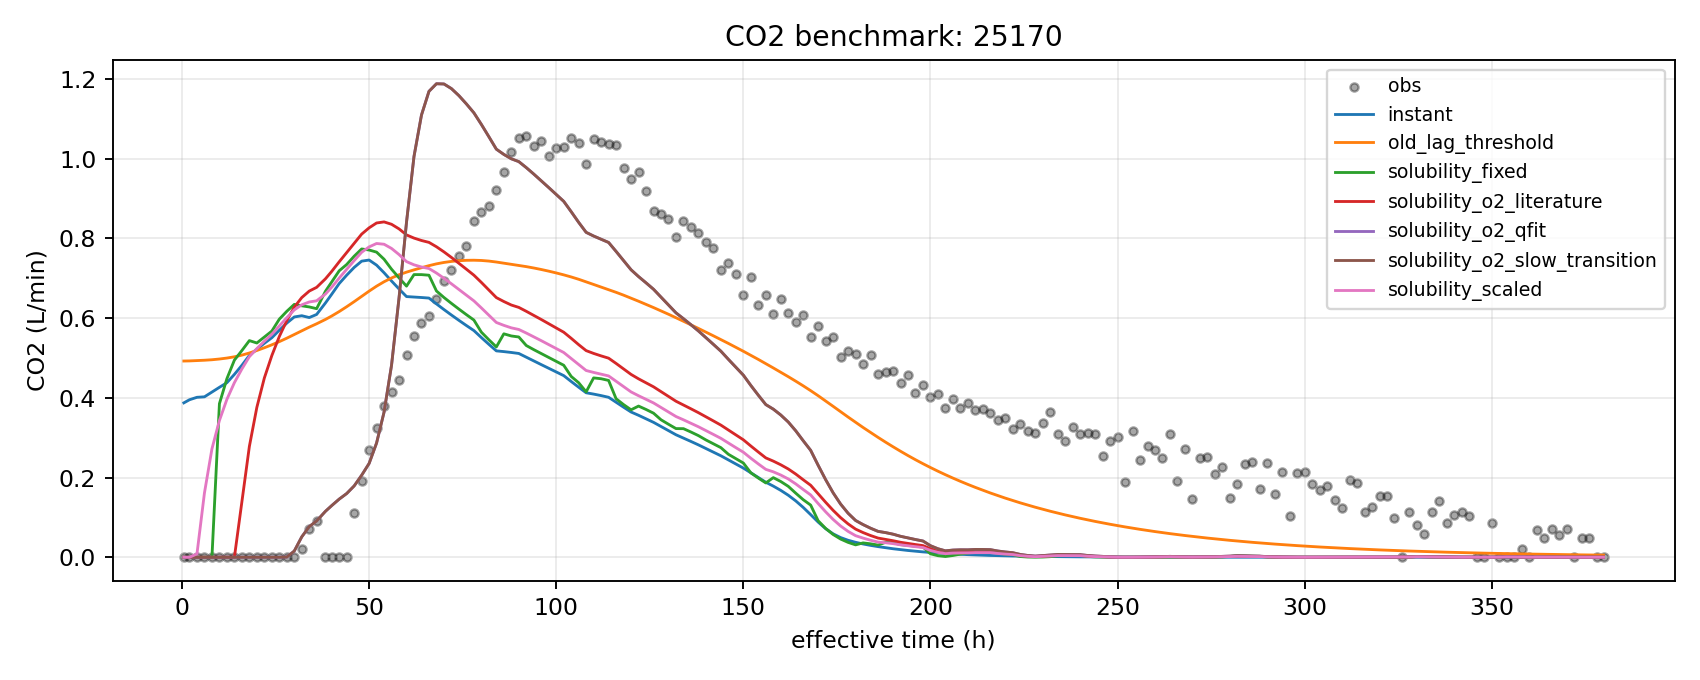

#### Laboratorio 2026 · holdout entre matrices

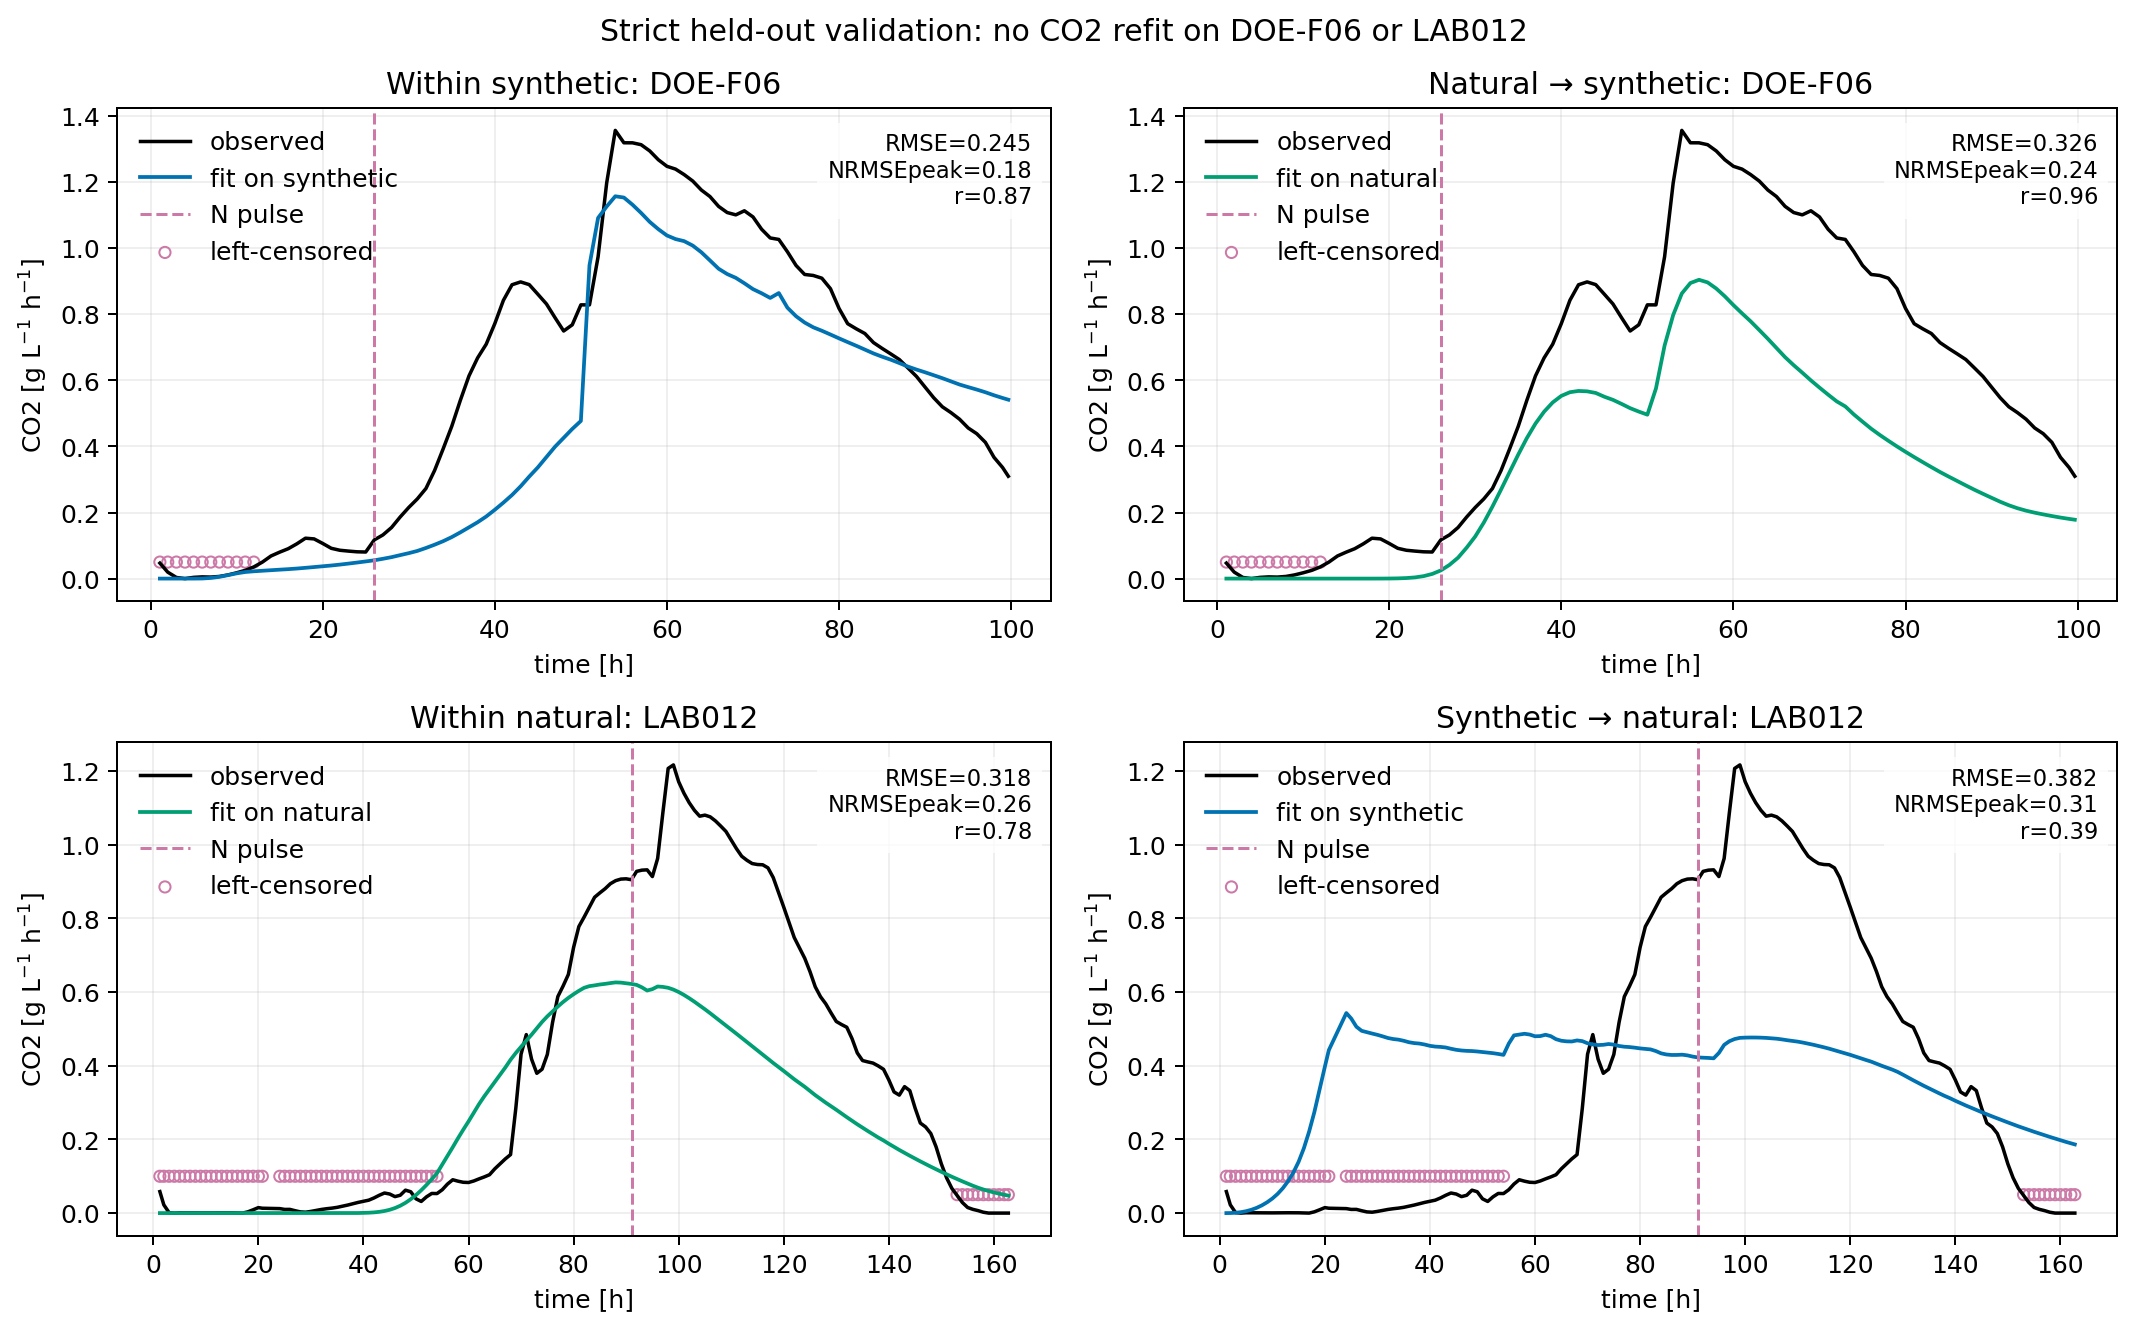

#### Piloto 2026 · holdout entre lotes

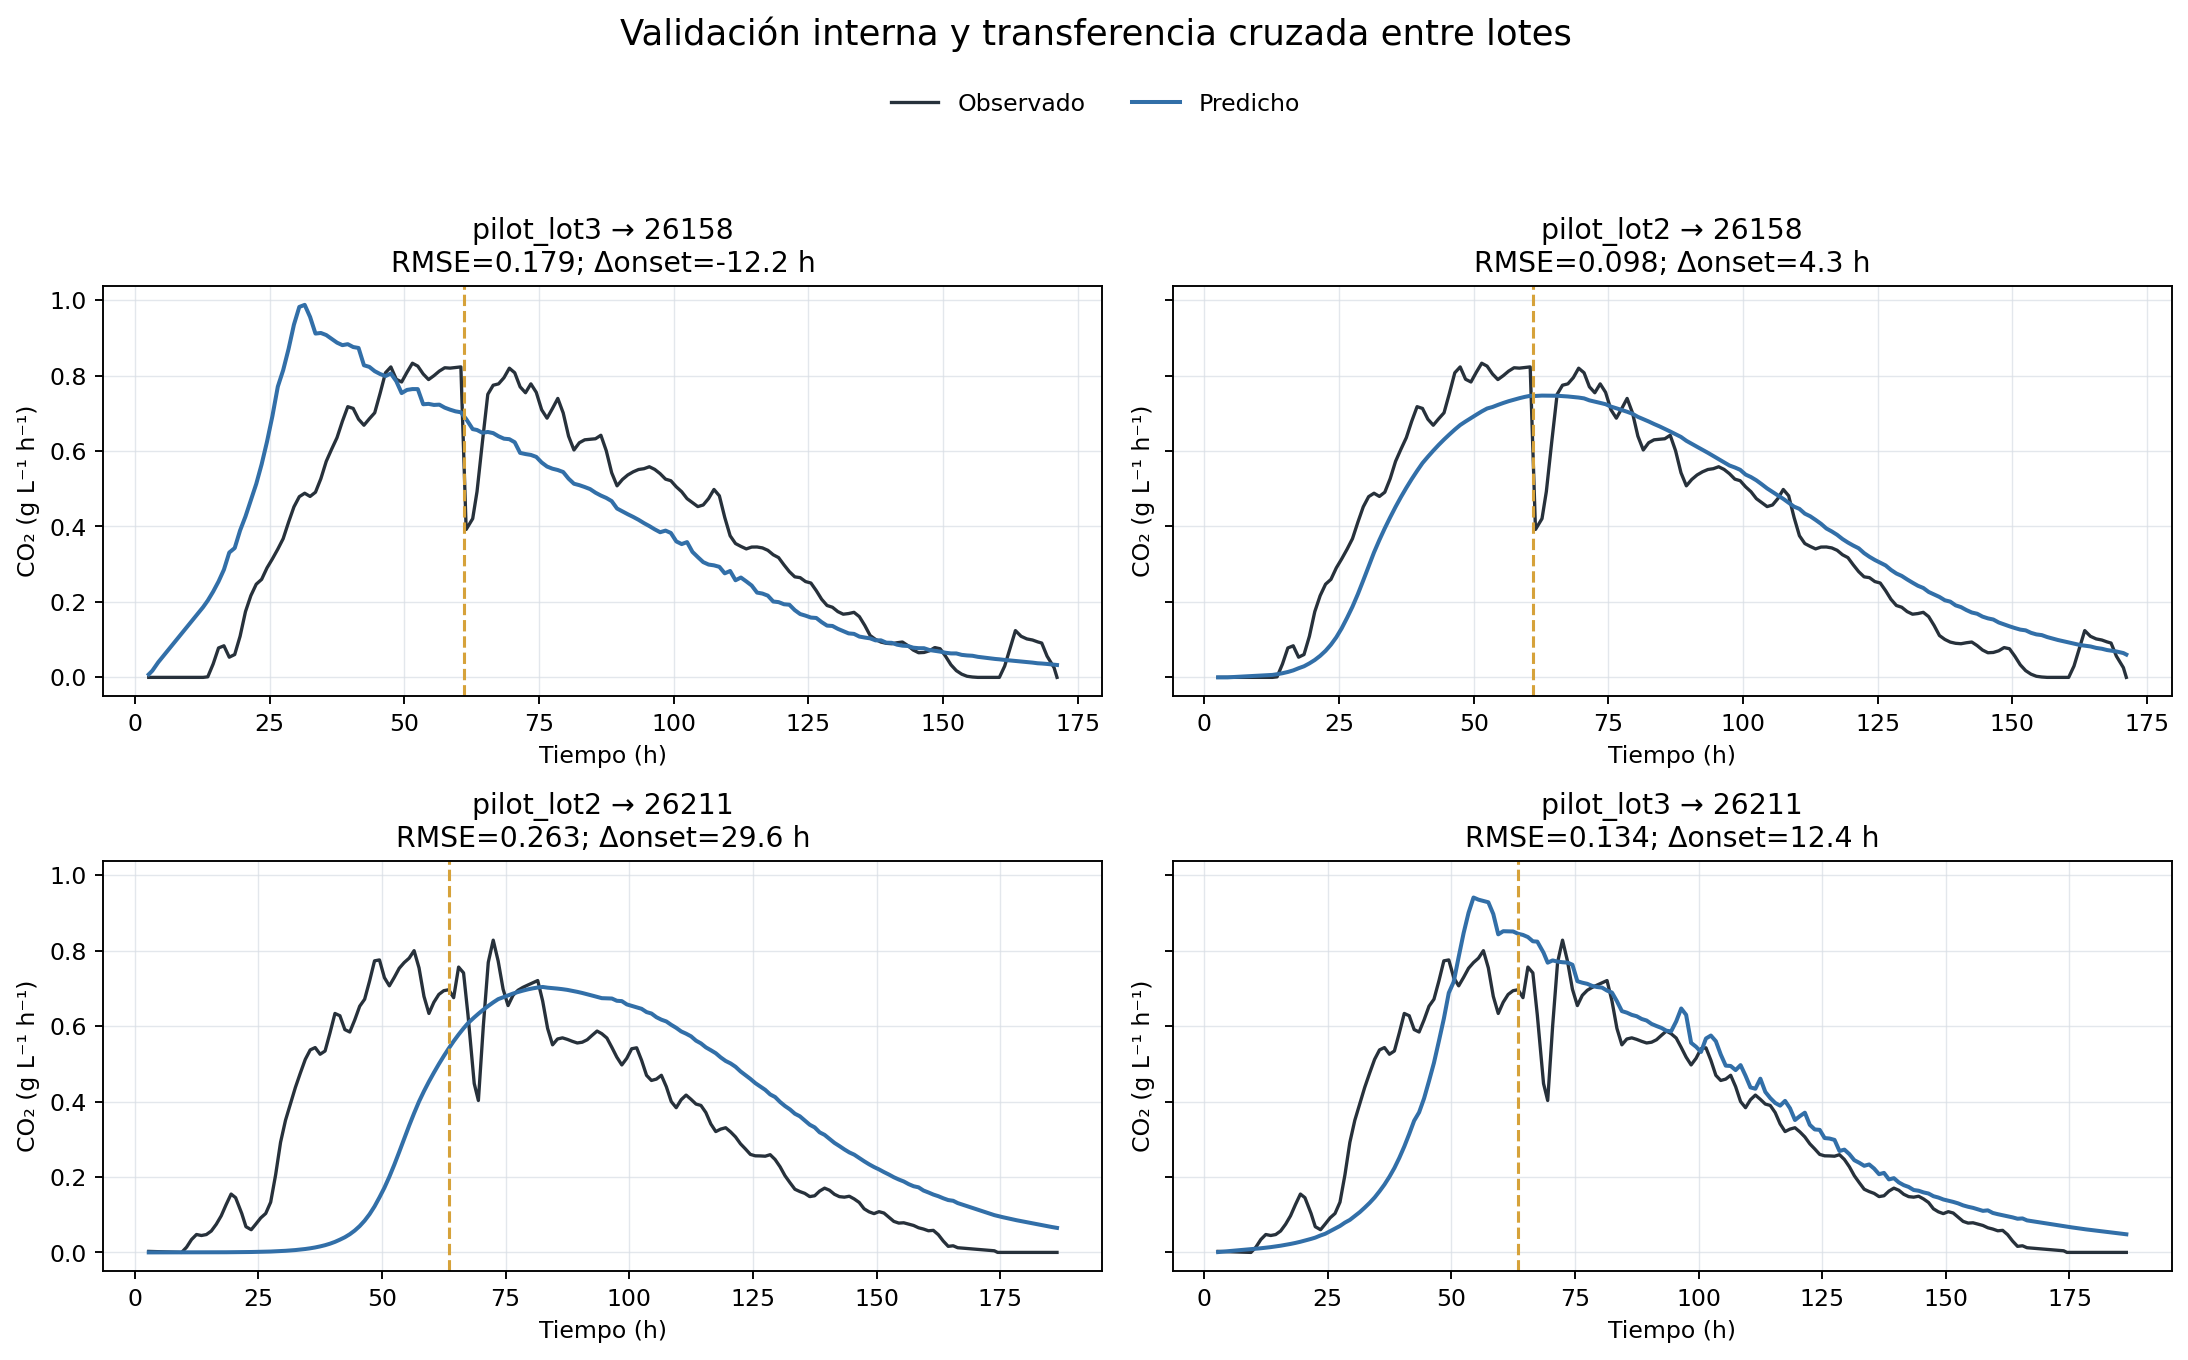

In [4]:
for label in (
    "piloto 2025 · comparación de formulaciones",
    "laboratorio 2026 · holdout entre matrices",
    "piloto 2026 · holdout entre lotes",
):
    display(Markdown(f"#### {label.capitalize()}"))
    display(Image(filename=str(reused[label]), width=1100))

**Lectura para la presentación.** El mejor comportamiento holdout aparece dentro de dominio: piloto 2026 alcanza (R^2=0.853) (lote 2) y (R^2=0.686) (lote 3). La transferencia es asimétrica: lote 3→2 conserva (R^2=0.510), mientras lote 2→3 cae a (R^2=-0.214); en laboratorio, sintética→natural llega a (R^2=-0.194). El parámetro de liberación cambia fuertemente entre dominios y varios parámetros alcanzan cotas. Por tanto, la **estructura** de liberación continua es transferible como hipótesis, pero todavía no existe evidencia para tratar todos sus parámetros como universales.

Como referencia compacta: piloto 2025 estimó (k_{\rm release}=0.2669\ \mathrm{h}^{-1}) y (s_{\rm CO2}=0.4066). En piloto 2026, (k_{\rm release}) fue 0.0461 h(^{-1}) en lote 2 y llegó a la cota superior (25 h(^{-1})) en lote 3; esta variación es una señal de correlación práctica entre liberación, solubilidad y activación, no una constante física ya cerrada.


## 4. Preprocesamiento de la medición: Hampel + Butterworth

Cadena histórica: muestreo a 10 s → detector Hampel causal (120 s, (k=3.5), umbral mínimo 0.5 sccm) → Butterworth de orden 3 con (	au=1200) s. La figura siguiente es material nuevo de presentación, pero usa los CSV y parámetros históricos ya guardados; no reestima ningún parámetro.


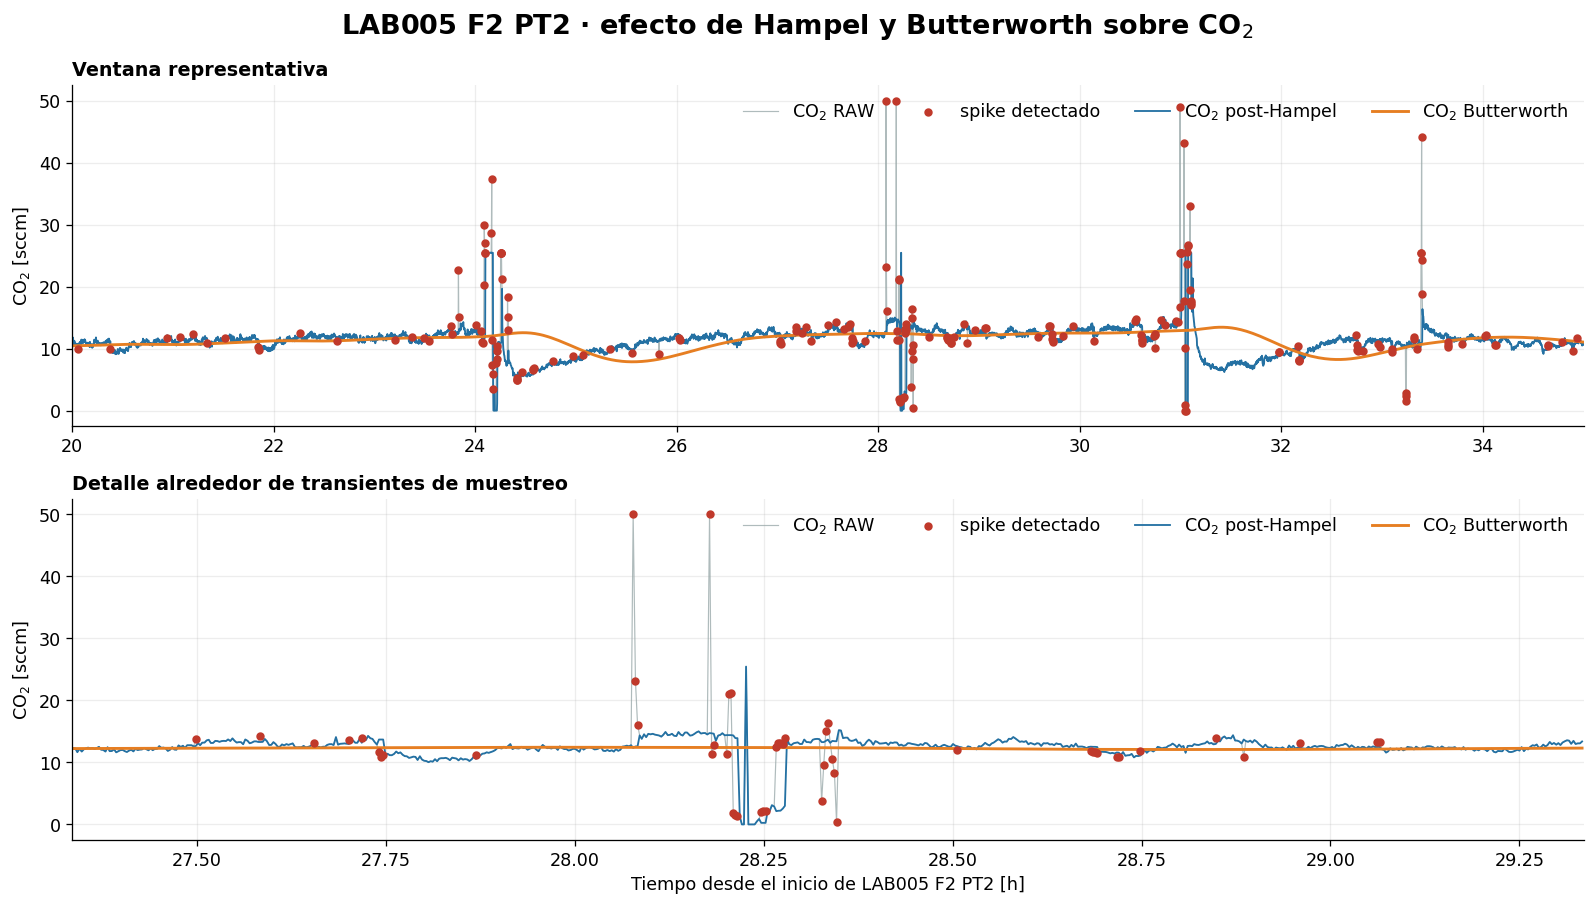

Muestreo: 10 s | Hampel: 120 s, k=3.5, umbral=0.5 sccm
Butterworth: orden 3, tau=1200 s
Guardada: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe\fermentation_model\laboratory_2026\results\presentation_figures\filter_signal_pipeline_lab005_pt2.png


In [5]:
filter_params = pd.read_csv(FILTER_RESULTS / "filter_parameters.csv")
params = dict(zip(filter_params["parameter"], filter_params["value"]))
HAMPEL_WINDOW_S = float(params["hampel_window_seconds"])
HAMPEL_K = float(params["hampel_k"])
MIN_ABS_SPIKE = float(params["hampel_min_abs_spike"])


def reconstruct_hampel(values, window_samples):
    """Misma regla causal documentada en co2_filter_delay_analysis_lab2026.ipynb."""
    buffer = deque(maxlen=max(1, int(window_samples)))
    output = np.empty(len(values), dtype=float)
    spikes = np.zeros(len(values), dtype=bool)
    for i, value in enumerate(np.asarray(values, dtype=float)):
        buffer.append(float(value))
        if len(buffer) < 3:
            output[i] = value
            continue
        array = np.asarray(buffer)
        median = float(np.median(array))
        mad = float(np.median(np.abs(array - median)))
        threshold = max(HAMPEL_K * 1.4826 * mad, MIN_ABS_SPIKE)
        spikes[i] = abs(value - median) > threshold
        output[i] = median if spikes[i] else value
    return output, spikes


raw = pd.read_csv(RAW_ROOT / "CO2_F2_LAB005_PT2.csv")
filt = pd.read_csv(RAW_ROOT / "CO2_FILT_F2_LAB005_PT2.csv")
raw["timestamp"] = pd.to_datetime(raw["timestamp"])
filt["timestamp"] = pd.to_datetime(filt["timestamp"])
raw = raw.sort_values("timestamp").drop_duplicates("timestamp")
filt = filt.sort_values("timestamp").drop_duplicates("timestamp")

dt_s = float(raw["timestamp"].diff().dt.total_seconds().median())
window_samples = int(round(HAMPEL_WINDOW_S / dt_s))
raw["co2_hampel"], raw["spike_reconstructed"] = reconstruct_hampel(
    raw["flow_sccm"].to_numpy(), window_samples
)

aligned = pd.merge_asof(
    filt[["timestamp", "flow_filt_sccm", "is_spike"]],
    raw[["timestamp", "flow_sccm", "co2_hampel", "spike_reconstructed"]],
    on="timestamp", direction="nearest", tolerance=pd.Timedelta(seconds=6),
).dropna(subset=["flow_sccm", "co2_hampel", "flow_filt_sccm"])

experiment_start = raw["timestamp"].iloc[0]
aligned["elapsed_h"] = (aligned["timestamp"] - experiment_start).dt.total_seconds() / 3600
shown = aligned.loc[aligned["elapsed_h"].between(20.0, 35.0)].copy()
spike_times = shown.loc[shown["is_spike"].astype(bool), "elapsed_h"]
zoom_center = float(spike_times.median()) if len(spike_times) else 27.0
zoom = shown.loc[shown["elapsed_h"].between(zoom_center - 1.0, zoom_center + 1.0)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharey=False)
for ax, frame, title in (
    (axes[0], shown, "Ventana representativa"),
    (axes[1], zoom, "Detalle alrededor de transientes de muestreo"),
):
    ax.plot(frame["elapsed_h"], frame["flow_sccm"], color="#95a5a6", lw=0.75,
            alpha=0.75, label=r"CO$_2$ RAW")
    marked = frame[frame["is_spike"].astype(bool)]
    ax.scatter(marked["elapsed_h"], marked["flow_sccm"], s=18, color="#c0392b",
               zorder=5, label="spike detectado")
    ax.plot(frame["elapsed_h"], frame["co2_hampel"], color="#2471a3", lw=1.15,
            label=r"CO$_2$ post-Hampel")
    ax.plot(frame["elapsed_h"], frame["flow_filt_sccm"], color="#e67e22", lw=1.8,
            label=r"CO$_2$ Butterworth")
    ax.set_ylabel(r"CO$_2$ [sccm]")
    ax.set_title(title, loc="left", fontsize=12, weight="bold")
    ax.legend(ncol=4, frameon=False, loc="upper right")

axes[0].set_xlim(20, 35)
axes[1].set_xlim(zoom_center - 1.0, zoom_center + 1.0)
axes[1].set_xlabel("Tiempo desde el inicio de LAB005 F2 PT2 [h]")
fig.suptitle(r"LAB005 F2 PT2 · efecto de Hampel y Butterworth sobre CO$_2$", fontsize=17, weight="bold")
fig.tight_layout()
filter_pipeline_path = PRESENTATION_FIGURES / "filter_signal_pipeline_lab005_pt2.png"
fig.savefig(filter_pipeline_path, bbox_inches="tight")
plt.show()

print(f"Muestreo: {dt_s:.0f} s | Hampel: {HAMPEL_WINDOW_S:.0f} s, k={HAMPEL_K:g}, umbral={MIN_ABS_SPIKE:g} sccm")
print(f"Butterworth: orden {int(float(params['butterworth_order']))}, tau={float(params['butterworth_tau']):.0f} s")
print("Guardada:", filter_pipeline_path)

### Retardo introducido por el filtrado

Con (	au=1200) s, el retardo de nivel observado fue aproximadamente 39–51 min según experimento (LAB005: 38.8 min); el retardo por derivadas fue aproximadamente 40–47 min (LAB005: 42.2 min). Es una demora suficientemente grande para que el estimador deba modelarla o compensarla explícitamente.


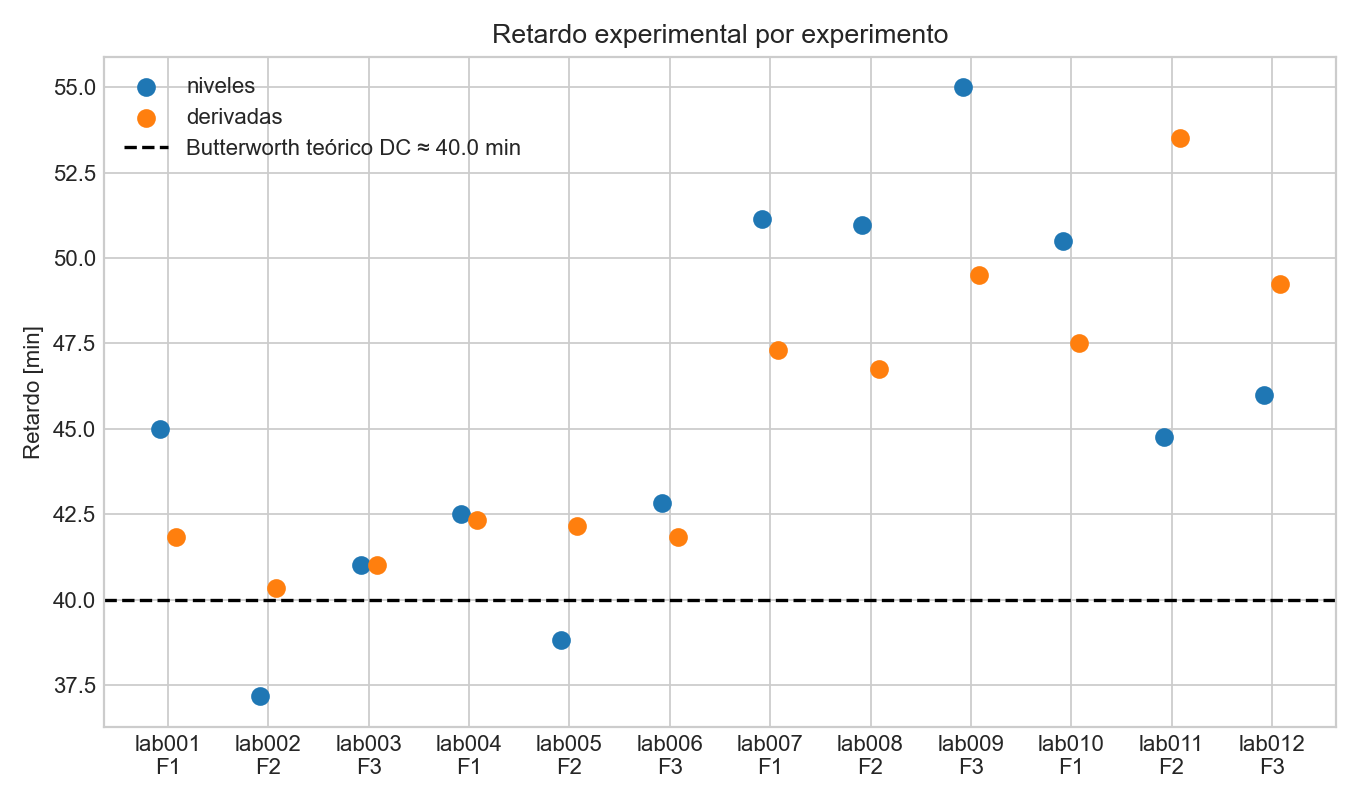

**Comparación solicitada de constantes de tiempo (300, 450, 600, 900 y 1200 s): PENDIENTE.** Los resultados actuales contienen solamente `tau = 1200 s`; por eso no se presenta una curva inventada de atenuación versus retardo.

In [6]:
display(Image(filename=str(reused["retardo por experimento"]), width=1050))

display(Markdown(
    "**Comparación solicitada de constantes de tiempo (300, 450, 600, 900 y 1200 s): PENDIENTE.** "
    "Los resultados actuales contienen solamente `tau = 1200 s`; por eso no se presenta una curva inventada de atenuación versus retardo."
))

## 5. Evidencia de acoplamiento temperatura–CO$_2$

La figura existente de LAB005 F2 PT2 usa una ventana común de 20–60 h para temperatura, estados HOT/COLD, CO$_2$ post-Hampel y filtrado, correlaciones, respuesta event-triggered, PSD y coherencia. Sirve como evidencia de que parte de la variación rápida de CO$_2$ puede estar asociada al control térmico; no demuestra causalidad biológica por sí sola.


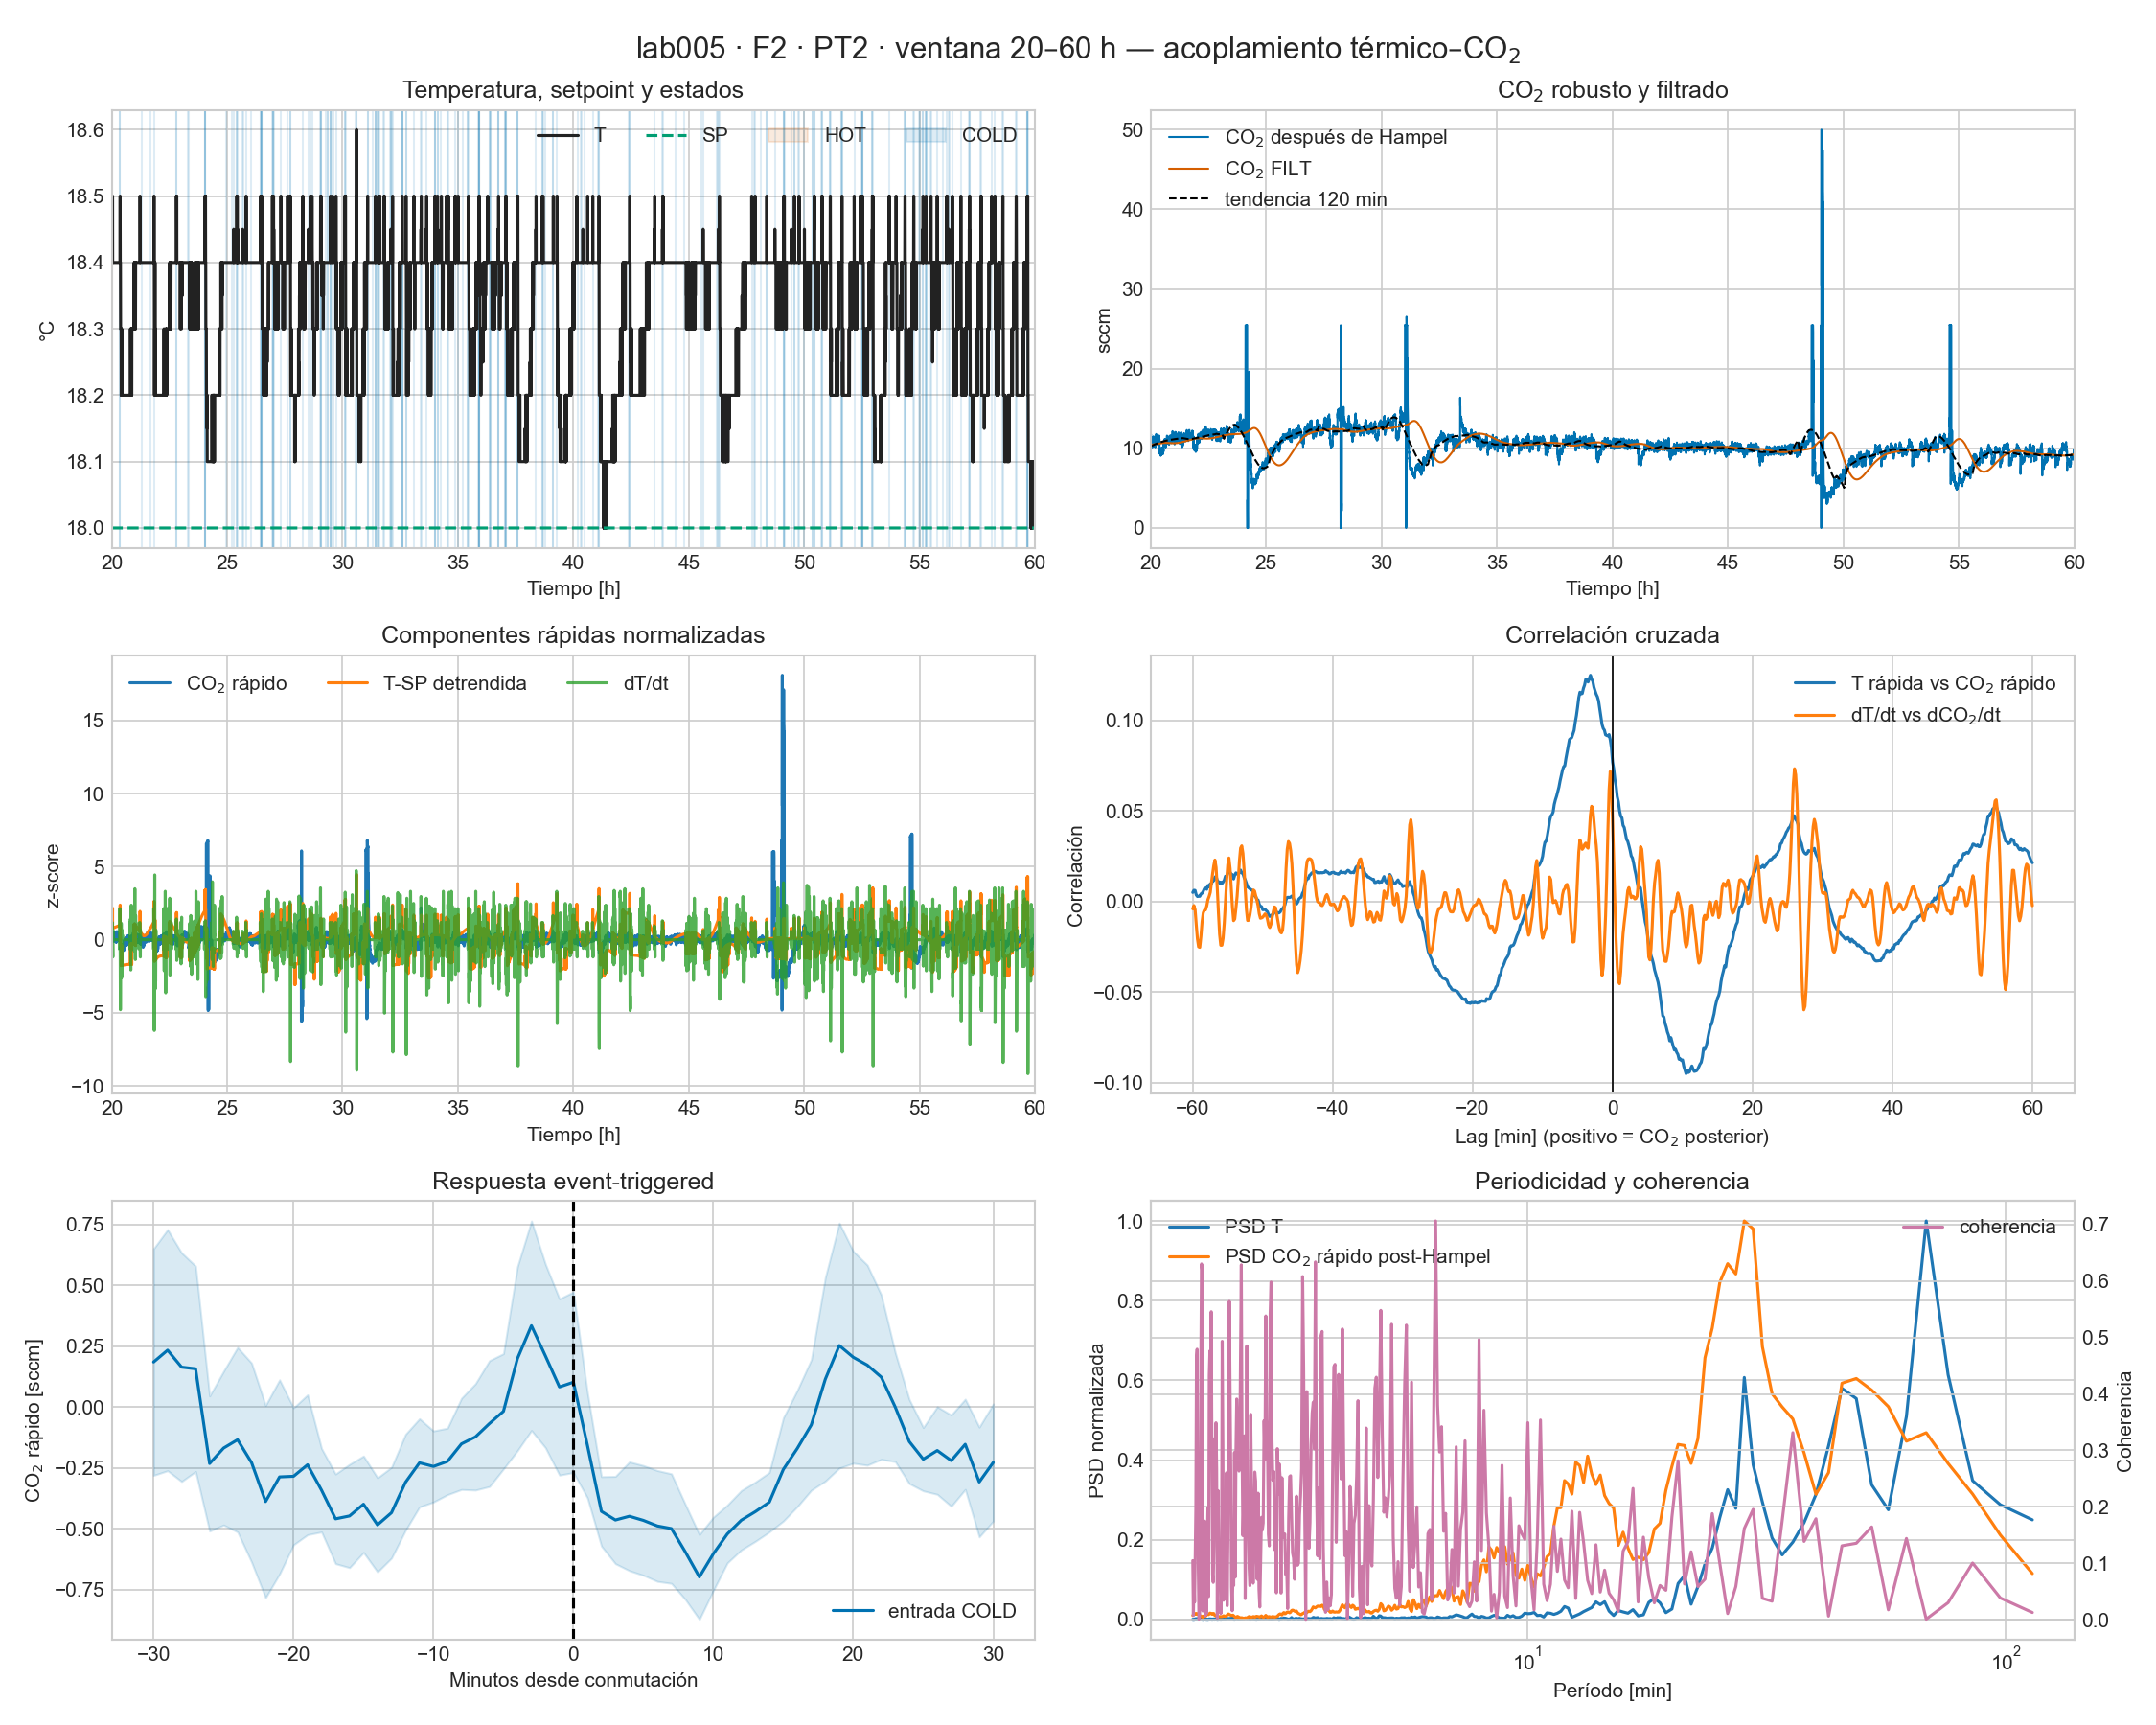

In [7]:
display(Image(filename=str(reused["acoplamiento térmico LAB005 F2 PT2"]), width=1150))

**Mensaje clave.** El estimador futuro debe recibir (T(t)) como entrada conocida y debe evitar atribuir automáticamente al estado biológico toda oscilación de CO$_2$ que siga al ciclo térmico. El análisis espectral y event-triggered orienta esa separación, pero todavía requiere validación en ensayos herméticos y replicados.


## 6. Arquitectura conceptual del estimador de Kalman

Estados objetivo: (hat x=[\hat X,\hat N,\hat S,\hat E]^\mathsf{T}). El modelo biológico predice los estados; el modelo de observación transforma esa predicción en CO$_2$ gaseoso. La medición pasa por la cadena robusta antes de formar la innovación. **O$_2$ no aparece como medición online.**


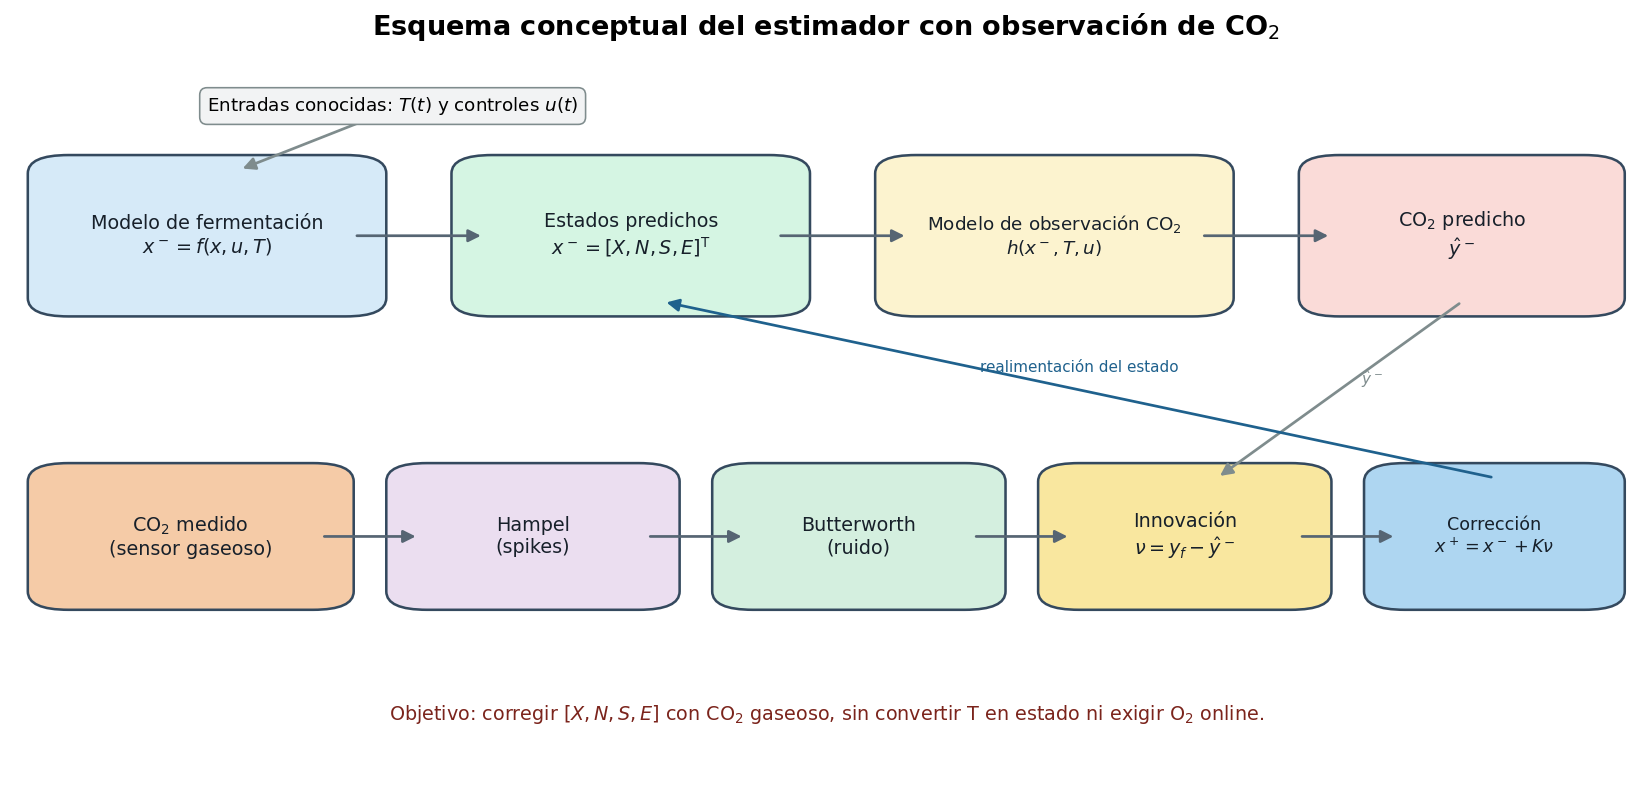

Guardada: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe\fermentation_model\laboratory_2026\results\presentation_figures\kalman_co2_concept_architecture.png


In [8]:
fig, ax = plt.subplots(figsize=(14.5, 7.0))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

add_box(ax, (0.03, 0.65), 0.18, 0.18,
        "Modelo de fermentación\n" + r"$x^-=f(x,u,T)$", "#d6eaf8", fontsize=12)
add_box(ax, (0.29, 0.65), 0.18, 0.18,
        "Estados predichos\n" + r"$x^-=[X,N,S,E]^\mathsf{T}$", "#d5f5e3", fontsize=12)
add_box(ax, (0.55, 0.65), 0.18, 0.18,
        r"Modelo de observación CO$_2$" + "\n" + r"$h(x^-,T,u)$", "#fcf3cf", fontsize=11.5)
add_box(ax, (0.81, 0.65), 0.16, 0.18,
        r"CO$_2$ predicho" + "\n" + r"$\hat y^-$", "#fadbd8", fontsize=12)

add_arrow(ax, (0.21, 0.74), (0.29, 0.74))
add_arrow(ax, (0.47, 0.74), (0.55, 0.74))
add_arrow(ax, (0.73, 0.74), (0.81, 0.74))

add_box(ax, (0.03, 0.25), 0.16, 0.16,
        r"CO$_2$ medido" + "\n(sensor gaseoso)", "#f5cba7", fontsize=12)
add_box(ax, (0.25, 0.25), 0.14, 0.16, "Hampel\n(spikes)", "#ebdef0", fontsize=12)
add_box(ax, (0.45, 0.25), 0.14, 0.16, "Butterworth\n(ruido)", "#d4efdf", fontsize=12)
add_box(ax, (0.65, 0.25), 0.14, 0.16,
        "Innovación\n" + r"$\nu=y_f-\hat y^-$", "#f9e79f", fontsize=12)
add_box(ax, (0.85, 0.25), 0.12, 0.16,
        "Corrección\n" + r"$x^+=x^-+K\nu$", "#aed6f1", fontsize=11)

add_arrow(ax, (0.19, 0.33), (0.25, 0.33))
add_arrow(ax, (0.39, 0.33), (0.45, 0.33))
add_arrow(ax, (0.59, 0.33), (0.65, 0.33))
add_arrow(ax, (0.79, 0.33), (0.85, 0.33))
add_arrow(ax, (0.89, 0.65), (0.74, 0.41), color="#7f8c8d", text=r"$\hat y^-$", text_offset=(0.02, 0.0))
add_arrow(ax, (0.91, 0.41), (0.40, 0.65), color="#1f618d", text="realimentación del estado", text_offset=(0.0, 0.02))

ax.text(0.12, 0.91, r"Entradas conocidas: $T(t)$ y controles $u(t)$", fontsize=11.5,
        bbox=dict(boxstyle="round,pad=0.4", fc="#f2f3f4", ec="#7f8c8d"))
add_arrow(ax, (0.22, 0.90), (0.14, 0.83), color="#7f8c8d")
ax.text(0.5, 0.08,
        r"Objetivo: corregir $[X,N,S,E]$ con CO$_2$ gaseoso, sin convertir T en estado ni exigir O$_2$ online.",
        ha="center", fontsize=12, color="#7b241c")
ax.set_title(r"Esquema conceptual del estimador con observación de CO$_2$", fontsize=17, weight="bold")

kalman_path = PRESENTATION_FIGURES / "kalman_co2_concept_architecture.png"
fig.tight_layout()
fig.savefig(kalman_path, bbox_inches="tight")
plt.show()
print("Guardada:", kalman_path)

## 7. Plan experimental y decisiones pendientes

Para cerrar la ecuación de observación y validar el estimador:

| Tipo de señal | Variables | Rol |
|---|---|---|
| Online | CO$_2$ gaseoso, temperatura, controles conocidos | entrada/observación del estimador |
| Offline | biomasa (X), nitrógeno (N), sustrato (S), etanol (E) | referencia independiente para validar estados |
| Validación de capa física (opcional) | CO$_2$ disuelto y O$_2$ | discriminar producción vs solubilidad/liberación; no son requisito online |

**Diseño prioritario:** repetir fermentaciones herméticas y con trazabilidad de caudal, porque las fugas confunden producción, acumulación y liberación. Incluir réplicas, cambios térmicos planificados y muestras offline sincronizadas.

**Pendientes antes del filtro de Kalman:**

- validar parámetros de liberación entre lotes, matrices y escalas;
- separar incertidumbre del modelo biológico de la capa de observación;
- cuantificar atenuación/retardo para (	au\in\{300,450,600,900,1200\}) s;
- definir covarianzas (Q) y (R), y probar observabilidad de ([X,N,S,E]);
- representar explícitamente el retardo del filtro en la innovación o usar una alternativa causal con menor demora.

**Cierre:** la formulación de liberación continua es la mejor base estructural disponible, pero sus parámetros aún no son universales. La próxima campaña debe priorizar identificabilidad y validación independiente de estados, no agregar complejidad antes de resolver esas ambigüedades.


In [9]:
generated = [
    PRESENTATION_FIGURES / "co2_model_architecture.png",
    PRESENTATION_FIGURES / "filter_signal_pipeline_lab005_pt2.png",
    PRESENTATION_FIGURES / "kalman_co2_concept_architecture.png",
]
display(Markdown("### Trazabilidad del material"))
display(pd.DataFrame({
    "tipo": ["reutilizada"] * len(reused) + ["nueva"] * len(generated),
    "archivo": [str(p.relative_to(ROOT)) for p in reused.values()] + [str(p.relative_to(ROOT)) for p in generated],
}).style.hide(axis="index"))
print("Resultado ausente documentado: barrido tau = 300, 450, 600, 900, 1200 s.")

### Trazabilidad del material

tipo,archivo
reutilizada,fermentation_model\pilot_2025\results\co2_solubility_integrated_doe\plots\co2_benchmark\co2_benchmark_25170.png
reutilizada,fermentation_model\laboratory_2026\results\co2_matrix_cross_validation_2026\figures\heldout_cross_matrix_validation.png
reutilizada,fermentation_model\pilot_2026\results\co2_solubility_cross_lot_validation_2026\figures\heldout_cross_lot_validation.png
reutilizada,fermentation_model\laboratory_2026\results\co2_filter_delay_analysis\figures\delay_comparison_by_experiment.png
reutilizada,fermentation_model\laboratory_2026\results\co2_filter_delay_analysis\figures\thermal_coupling_lab005_F2_pt2.png
nueva,fermentation_model\laboratory_2026\results\presentation_figures\co2_model_architecture.png
nueva,fermentation_model\laboratory_2026\results\presentation_figures\filter_signal_pipeline_lab005_pt2.png
nueva,fermentation_model\laboratory_2026\results\presentation_figures\kalman_co2_concept_architecture.png


Resultado ausente documentado: barrido tau = 300, 450, 600, 900, 1200 s.
